In [1]:
%matplotlib widget

import lmfit
import matplotlib.pyplot as plt
from multiprocessing import Pool
import numpy as np
import pandas as pd
import sys
from tqdm.notebook import tqdm
import xarray as xr

import fitting_tools as dfit
from TASsello import f1f2Sim

In [2]:
# Define Gaussian function
def gaussian_2d(x, y, FWHM_x, FWHM_y=None):
    """Generate 2D Gaussian function."""
    sigma_x = FWHM_x / 2.3548
    if FWHM_y is None:
        sigma_y = sigma_x
    else:
        sigma_y = FWHM_y / 2.3548
    return np.exp(-(x**2 / (2 * sigma_x**2) + y**2 / (2 * sigma_y**2)))

In [9]:
xspan = 40
yspan = xspan
tspan = 60

xgrid = 2
ygrid = xgrid
tgrid = 2

x = np.linspace(-0.5*xspan, 0.5*xspan, xgrid)
y = x
t = np.linspace(0, tspan, tgrid)

In [10]:
pulse_energy = 1e-6
focus = 20

# Create 2D mesh grid
X, Y = np.meshgrid(x, y)

# Compute the Gaussian over the entire grid
field_yx = gaussian_2d(X, Y, focus)
field_yx *= pulse_energy / np.trapezoid(np.trapezoid(field_yx, x, axis=1), y, axis=0)

1e-06


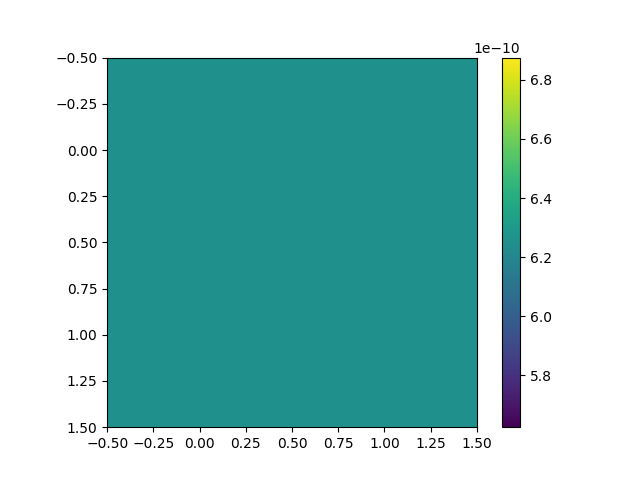

In [11]:
print(np.trapezoid(np.trapezoid(field_yx, x, axis=1), y, axis=0))

plt.figure()
plt.imshow(field_yx)
plt.colorbar()
plt.show()

In [12]:
sim = f1f2Sim()
def simulate(grid_point):
    ix, iy, t = grid_point
    sim.set_sim_params(field_yx[iy,ix], t)
    f1, f2 = sim.get_f1_f2()
    return {'ix': ix, 'iy': iy, 't': t, 'f1': f1, 'f2': f2}

In [13]:
grid_points = [(ix, iy, tt) for ix in range(int(xgrid/2)) for iy in range(int(ygrid/2)) for tt in t]

In [14]:
with Pool(processes=4) as pool:
    results = list(tqdm(pool.imap_unordered(simulate, grid_points), total=len(grid_points)))

  0%|          | 0/2 [00:00<?, ?it/s]

In [15]:
# Expand dictionaries to include energy index
expanded_data = []
for d in results:
    for i, e in enumerate(sim.egrid):
        expanded_data.append({'x': d['ix'], 'y': d['iy'], 't': d['t'], 'energy': e, 'f1': d['f1'][i], 'f2': d['f2'][i]})
del results

# Convert to DataFrame
df = pd.DataFrame(expanded_data)

# Convert to xarray Dataset
ds = df.set_index(['x', 'y', 't', 'energy']).to_xarray()

In [16]:
ds

<xarray.Dataset> Size: 40kB
Dimensions:  (x: 1, y: 1, t: 2, energy: 1000)
Coordinates:
  * x        (x) int64 8B 0
  * y        (y) int64 8B 0
  * t        (t) float64 16B 0.0 60.0
  * energy   (energy) float64 8kB 880.0 880.1 880.2 880.3 ... 979.8 979.9 980.0
Data variables:
    f1       (x, y, t, energy) float64 16kB 13.31 13.3 13.3 ... 15.37 15.37
    f2       (x, y, t, energy) float64 16kB 2.308 2.308 2.319 ... 12.08 12.07

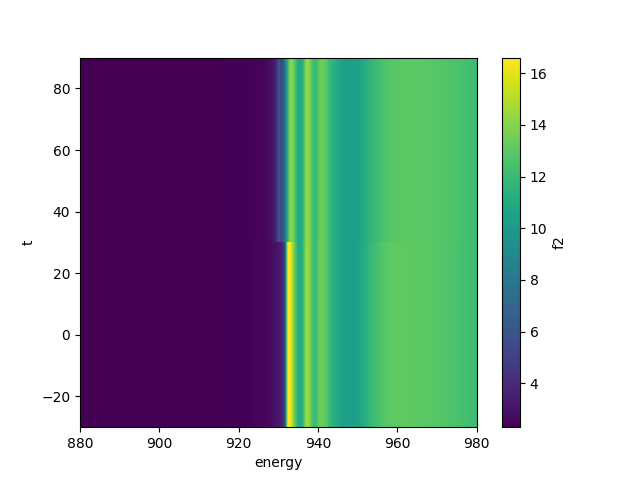

In [17]:
plt.figure()
ds['f2'].mean(dim=['x', 'y']).plot()
plt.show()

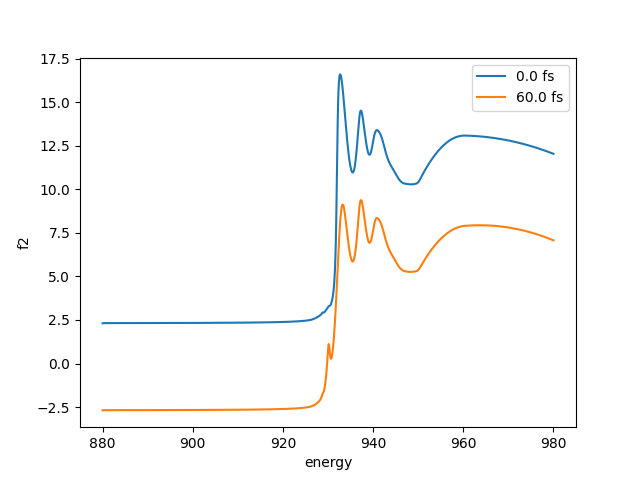

In [18]:
shift = 5
plt.figure()
for i, tt in enumerate(ds['t']):
    dplot = ds['f2'].sel(x=4, y=4, t=tt, method='nearest')
    (dplot-(i*shift)).plot(label=f'{tt.values:.1f} fs')
plt.legend()
plt.title('')
plt.show()

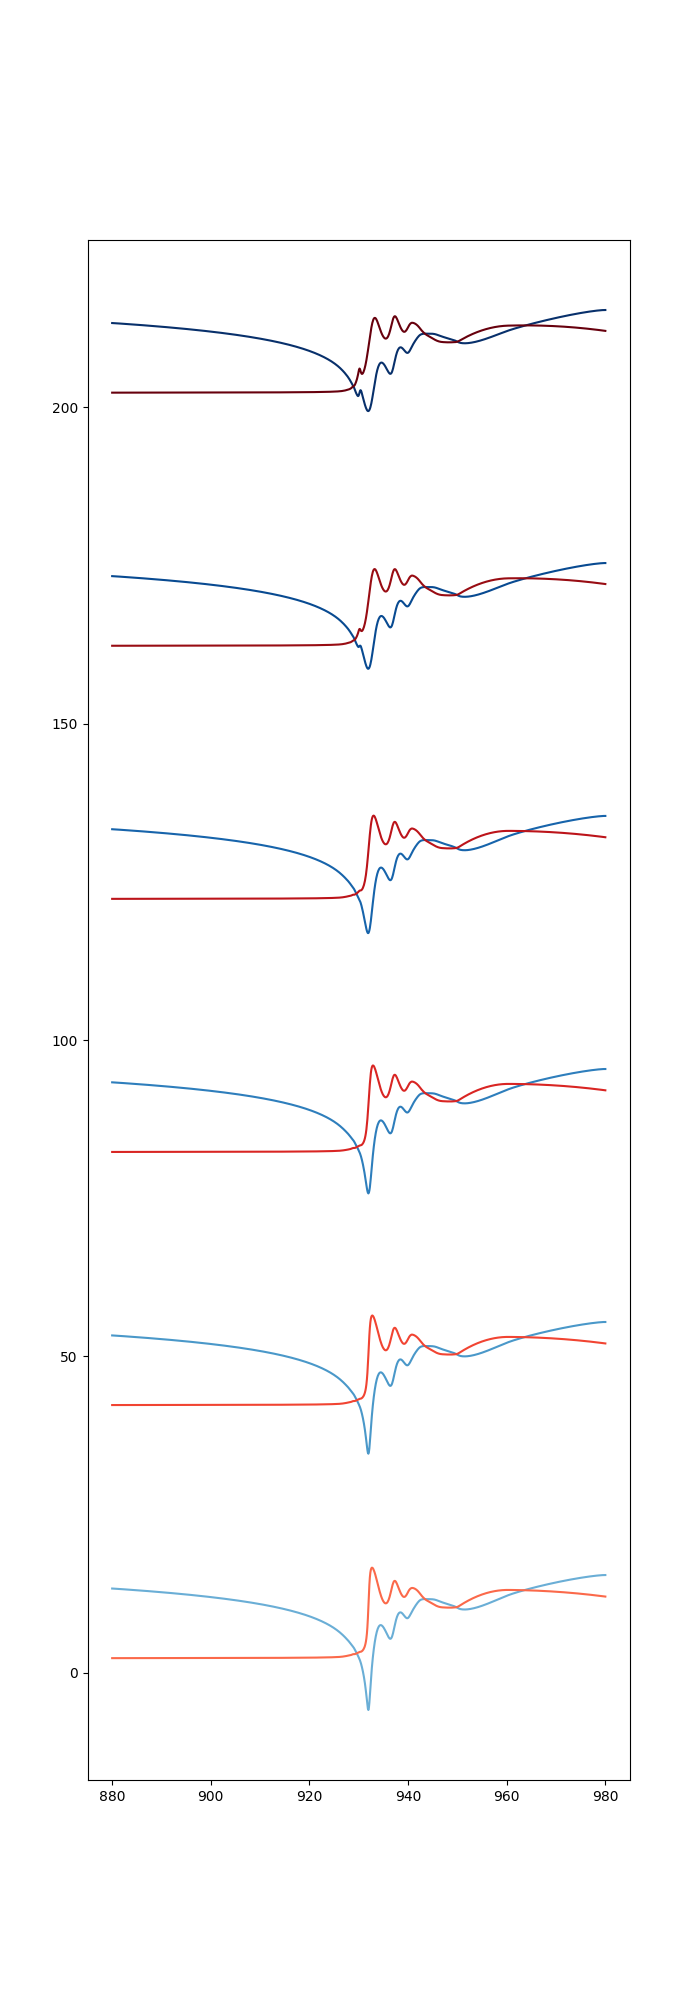

In [19]:
waterfall = 40  # Vertical shift for clarity
colors_f1 = plt.cm.Blues(np.linspace(0.5, 1, 6))  # Shades of blue for f1
colors_f2 = plt.cm.Reds(np.linspace(0.5, 1, 6))   # Shades of red for f2

# Start plotting
plt.figure(figsize=(7, 20))
for i, tt in enumerate([0, 20, 25, 30, 40, 60]):
    sim.set_sim_params(1e-6, tt)
    f1, f2 = sim.get_f1_f2()
    plt.plot(sim.egrid, f1+(i*waterfall), c=colors_f1[i])
    plt.plot(sim.egrid, f2+(i*waterfall), c=colors_f2[i])
plt.show()